### Applied ML (Supervised learning)

#### Datasets

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer, make_classification, make_blobs


In [2]:
flower_data = pd.read_table('datasets/fruit_data_with_colors.txt')

color_map =ListedColormap(['#FFFF00', '#00FF00', '#0000FF','#000000'])

In [3]:
flower_data.tail()

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
54,4,lemon,unknown,116,6.1,8.5,0.71
55,4,lemon,unknown,116,6.3,7.7,0.72
56,4,lemon,unknown,116,5.9,8.1,0.73
57,4,lemon,unknown,152,6.5,8.5,0.72
58,4,lemon,unknown,118,6.1,8.1,0.70


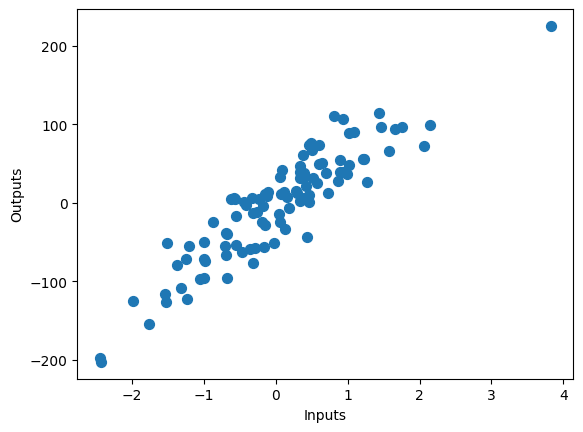

In [4]:
# simple Linear Regression model

from sklearn.datasets import make_regression

X_1, y_1 = make_regression(
    n_samples = 100,
    n_features = 1,
    n_informative = 1,
    n_targets = 1,
    noise = 30
)

plt.figure()
plt.xlabel("Inputs")
plt.ylabel("Outputs")
plt.scatter(X_1, y_1, marker ='o', s=50)


In [5]:
# synthetic dataset for complext regression

from sklearn.datasets import make_friedman1

X_2, y_2 = make_friedman1(
    n_samples = 100,
    n_features = 10,
    noise = 0
)

In [6]:
X_2[:,2].shape

(100,)

In [7]:
y_2.shape

(100,)

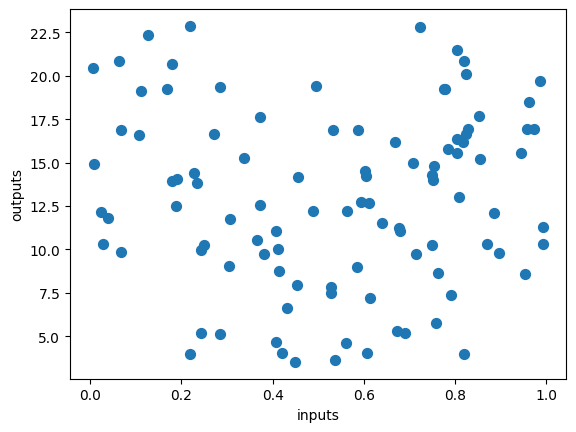

In [8]:
plt.figure()
plt.xlabel("inputs")
plt.ylabel("outputs")
plt.scatter(X_2[:,2],y_2, marker='o', s=50)
plt.show()

In [9]:
# random dataset for binary classification

X_3, y_3 = make_classification(
    n_samples = 100,
    n_features = 4, 
    n_informative = 3,
    n_redundant = 1,
    n_clusters_per_class = 4,
    random_state = 0
)

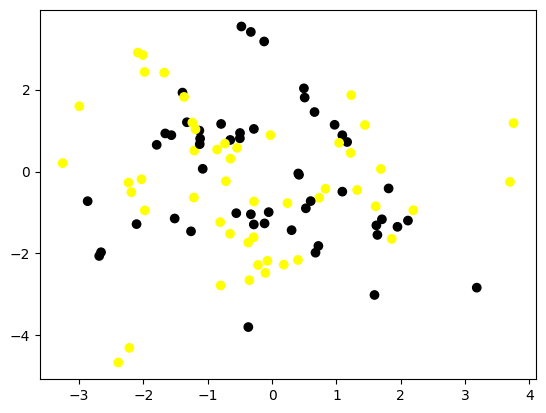

In [10]:
plt.scatter(X_3[:,0], X_3[:,1],c=y_3, marker ='o',cmap=color_map)
plt.show()

## Naive Bayes Classifier

In [11]:
from sklearn.naive_bayes import GaussianNB

#use the synthetic classification datasets X_3, y_3
# using different train test splits
train_split = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]

for i in train_split:
    X_train,X_test,y_train,y_test = train_test_split(X_3, y_3,train_size=i, random_state=0)
    nb_classifier = GaussianNB().fit(X_train, y_train)

    # score on test dataset
    print("train size", i)
    print("This is the score on the test dataset:",nb_classifier.score(X_test, y_test))

    # training score
    print("this is the score on the training set:",nb_classifier.score(X_train, y_train))
    print("\n")


train size 0.1
This is the score on the test dataset: 0.7444444444444445
this is the score on the training set: 0.9


train size 0.2
This is the score on the test dataset: 0.825
this is the score on the training set: 0.95


train size 0.3
This is the score on the test dataset: 0.8428571428571429
this is the score on the training set: 0.9333333333333333


train size 0.4
This is the score on the test dataset: 0.85
this is the score on the training set: 0.825


train size 0.5
This is the score on the test dataset: 0.86
this is the score on the training set: 0.84


train size 0.6
This is the score on the test dataset: 0.825
this is the score on the training set: 0.8666666666666667


train size 0.7
This is the score on the test dataset: 0.7666666666666667
this is the score on the training set: 0.8714285714285714


train size 0.8
This is the score on the test dataset: 0.85
this is the score on the training set: 0.8375


train size 0.9
This is the score on the test dataset: 0.9
this is the sc

### application to actual problems

#### using the breast cancer dataset

In [12]:
breast_cancer = load_breast_cancer()

In [13]:
X_cancer = breast_cancer.data
y_cancer = breast_cancer.target

In [14]:
train_split = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in train_split:
    X_train, X_test,y_train, y_test = train_test_split(X_cancer, y_cancer, train_size=i ,random_state = 0 )
    nb_breast_cancer = GaussianNB().fit(X_train, y_train)

    # score on test dataset
    print("train size", i)
    print("This is the score on the test dataset:",nb_breast_cancer.score(X_test, y_test))

    # training score
    print("this is the score on the training set:",nb_breast_cancer.score(X_train, y_train))
    print("\n")

train size 0.1
This is the score on the test dataset: 0.9337231968810916
this is the score on the training set: 0.9464285714285714


train size 0.2
This is the score on the test dataset: 0.9210526315789473
this is the score on the training set: 0.9646017699115044


train size 0.3
This is the score on the test dataset: 0.9373433583959899
this is the score on the training set: 0.9588235294117647


train size 0.4
This is the score on the test dataset: 0.935672514619883
this is the score on the training set: 0.9559471365638766


train size 0.5
This is the score on the test dataset: 0.9368421052631579
this is the score on the training set: 0.9507042253521126


train size 0.6
This is the score on the test dataset: 0.9298245614035088
this is the score on the training set: 0.9472140762463344


train size 0.7
This is the score on the test dataset: 0.9239766081871345
this is the score on the training set: 0.9422110552763819


train size 0.8
This is the score on the test dataset: 0.92982456140350

### NEURAL NETWORKS

##### activation functions

In [15]:
xrange = np.linspace(-2,2,200)

In [16]:
xrange

array([-2.        , -1.9798995 , -1.95979899, -1.93969849, -1.91959799,
       -1.89949749, -1.87939698, -1.85929648, -1.83919598, -1.81909548,
       -1.79899497, -1.77889447, -1.75879397, -1.73869347, -1.71859296,
       -1.69849246, -1.67839196, -1.65829146, -1.63819095, -1.61809045,
       -1.59798995, -1.57788945, -1.55778894, -1.53768844, -1.51758794,
       -1.49748744, -1.47738693, -1.45728643, -1.43718593, -1.41708543,
       -1.39698492, -1.37688442, -1.35678392, -1.33668342, -1.31658291,
       -1.29648241, -1.27638191, -1.25628141, -1.2361809 , -1.2160804 ,
       -1.1959799 , -1.1758794 , -1.15577889, -1.13567839, -1.11557789,
       -1.09547739, -1.07537688, -1.05527638, -1.03517588, -1.01507538,
       -0.99497487, -0.97487437, -0.95477387, -0.93467337, -0.91457286,
       -0.89447236, -0.87437186, -0.85427136, -0.83417085, -0.81407035,
       -0.79396985, -0.77386935, -0.75376884, -0.73366834, -0.71356784,
       -0.69346734, -0.67336683, -0.65326633, -0.63316583, -0.61

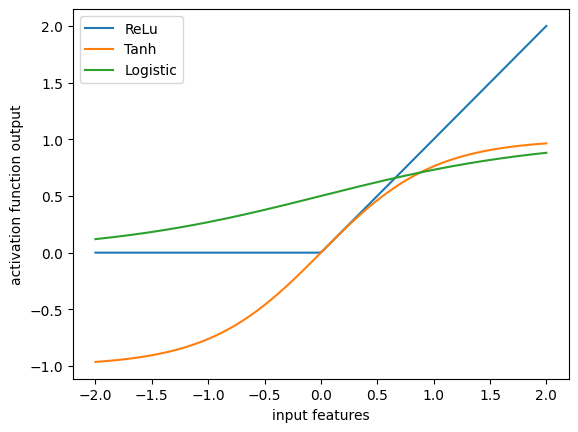

In [17]:
plt.figure()

plt.plot(xrange, np.maximum(xrange, 0), label = "ReLu")
plt.plot(xrange, np.tanh(xrange), label = "Tanh")
plt.plot(xrange, 1/(1 + np.exp(-xrange)), label = "Logistic")
plt.legend()

plt.xlabel("input features")
plt.ylabel("activation function output")
plt.show()

### Classification with neural networks

#### one hidden layer

In [26]:
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

In [29]:
#create the dataset
X_blobs , y_blobs = make_blobs(n_samples = 100,
                              n_features = 4,
                              centers = 8,
                              random_state=0)

#split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_blobs,
                                                    y_blobs, 
                                                    train_size = 0.7, 
                                                    random_state = 0)

pd.DataFrame(X_blobs).head()

,0,1,2,3
0,0.088484,2.322991,1.707355,1.054013
1,-0.038652,4.813771,-0.069476,7.655535
2,-6.861259,1.614540,-9.792106,9.499698
3,-2.700027,4.861503,-1.661875,7.088005
4,-9.390402,3.249355,-7.816945,10.552929


In [31]:
MLPClassifier?

Init signature:
MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    *,
    solver='adam',
    alpha=0.0001,
    batch_size='auto',
    learning_rate='constant',
    learning_rate_init=0.001,
    power_t=0.5,
    max_iter=200,
    shuffle=True,
    random_state=None,
    tol=0.0001,
    verbose=False,
    warm_start=False,
    momentum=0.9,
    nesterovs_momentum=True,
    early_stopping=False,
    validation_fraction=0.1,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-08,
    n_iter_no_change=10,
    max_fun=15000,
)
Docstring:     
Multi-layer Perceptron classifier.

This model optimizes the log-loss function using LBFGS or stochastic
gradient descent.

.. versionadded:: 0.18

Parameters
----------
hidden_layer_sizes : array-like of shape(n_layers - 2,), default=(100,)
    The ith element represents the number of neurons in the ith
    hidden layer.

activation : {'identity', 'logistic', 'tanh', 'relu'}, default='relu'
    Activation function for the hidden laye

In [45]:
hidden_layers = [1, 10, 100]
for i in hidden_layers:
    #define the classifier object
    neural_net_cl = MLPClassifier(hidden_layer_sizes = (i,),
                              activation = 'relu',
                              solver ='sgd',
                              alpha = 0.0001,
                              max_iter = 2000,
                              random_state = 0,
                             ).fit(X_train, y_train)

    #trial x 
    tr_x = np.array([[ -6.26997963,   2.10897124,  -7.78522785,   8.37218903]]) # expected output = 6
    print("hidden layers ", i)
    print("score: ",neural_net_cl.score(X_test, y_test))
    print("test:", neural_net_cl.predict(tr_x))

hidden layers  1
score:  0.3333333333333333
test: [7]
hidden layers  10
score:  1.0
test: [6]
hidden layers  100
score:  1.0
test: [6]


In [48]:
y_test[0]

np.int64(6)

In [43]:
X_train[0]

array([-6.26997963,  2.10897124, -7.78522785,  8.37218903])